<a href="https://colab.research.google.com/github/pitagorasman/Tareas-Computo-Cientifico/blob/main/Taller_I_Compresi%C3%B3n_de_Im%C3%A1genes_mediante_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sube tu imagen (Formatos recomendados: .jpg, .png, .jpeg):


Saving DSC_3634.JPG to DSC_3634.JPG
Archivo 'DSC_3634.JPG' cargado con éxito.

Dimensiones de la matriz original: 2000x3008


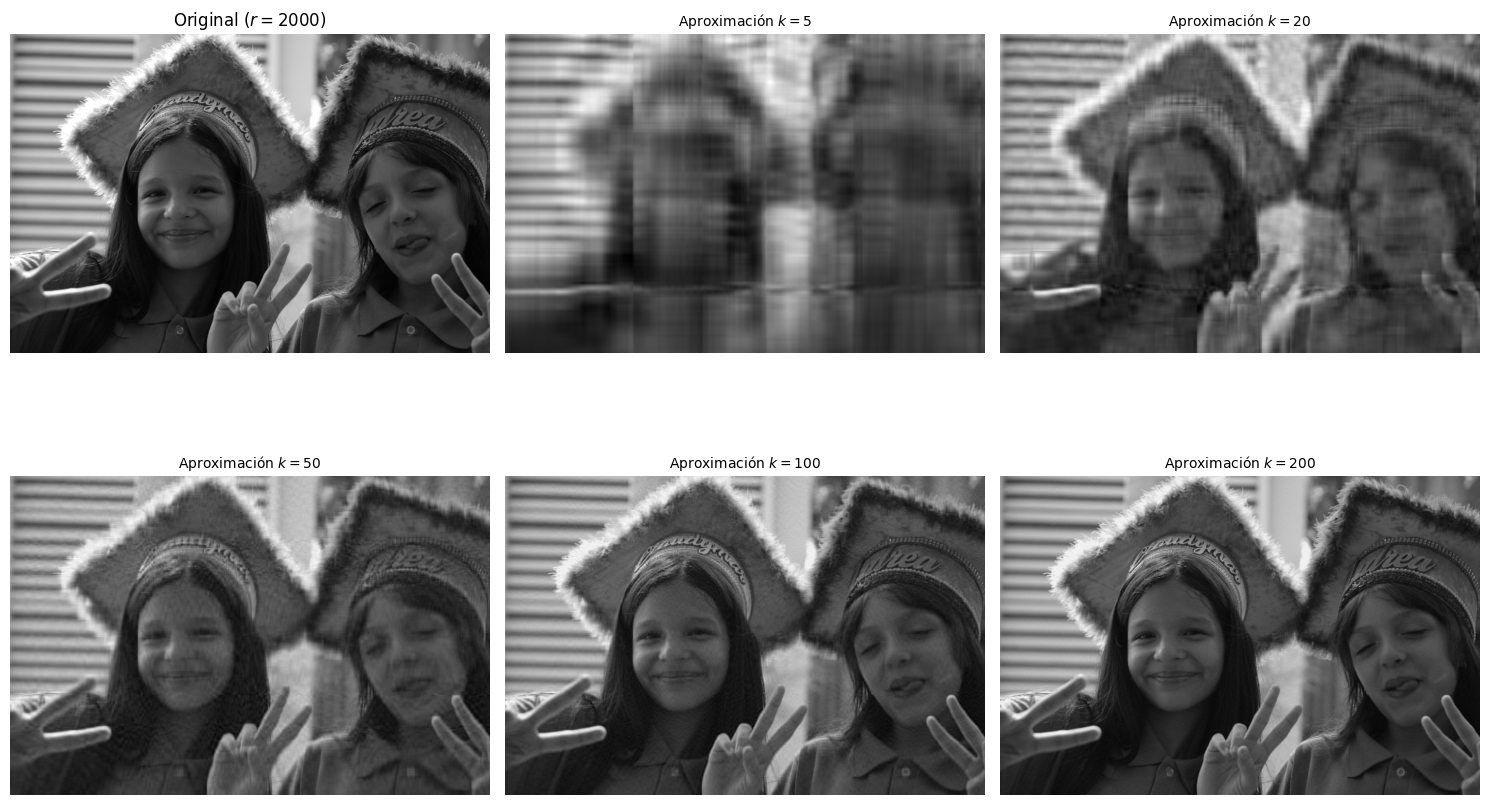

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import os

# 1. CARGA DE IMAGEN POR EL USUARIO

try:
    from google.colab import files
    print("Sube tu imagen (Formatos recomendados: .jpg, .png, .jpeg):")
    uploaded = files.upload()
    nombre_archivo = list(uploaded.keys())[0]
    print(f"Archivo '{nombre_archivo}' cargado con éxito.")
except ImportError:
    nombre_archivo = "tu_imagen.jpg"
    if not os.path.exists(nombre_archivo):
        print(f"Por favor, asegúrate de colocar la imagen '{nombre_archivo}' en la misma carpeta de tu script.")

imagen_usuario = io.imread(nombre_archivo)


if len(imagen_usuario.shape) == 3:
    A = color.rgb2gray(imagen_usuario)
else:
    A = imagen_usuario.astype(float) / 255.0

m, n = A.shape
print(f"\nDimensiones de la matriz original: {m}x{n}")

# 2. CALCULAR LA SVD

U, S, Vt = np.linalg.svd(A, full_matrices=False)

# 3. CONSTRUIR APROXIMACIONES A_k

k_values = [5, 20, 50, 100, 200]
A_k_approximations = {}

for k in k_values:
    k_actual = min(k, len(S))
    A_k = U[:, :k_actual] @ np.diag(S[:k_actual]) @ Vt[:k_actual, :]
    A_k_approximations[k] = A_k


# 4. VISUALIZAR LAS RECONSTRUCCIONES


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

axes[0].imshow(A, cmap='gray')
axes[0].set_title(f'Original ($r={min(m, n)}$)')
axes[0].axis('off')

for i, k in enumerate(k_values):
    ax = axes[i + 1]
    ax.imshow(A_k_approximations[k], cmap='gray')
    ax.set_title(f'Aproximación $k={k}$', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

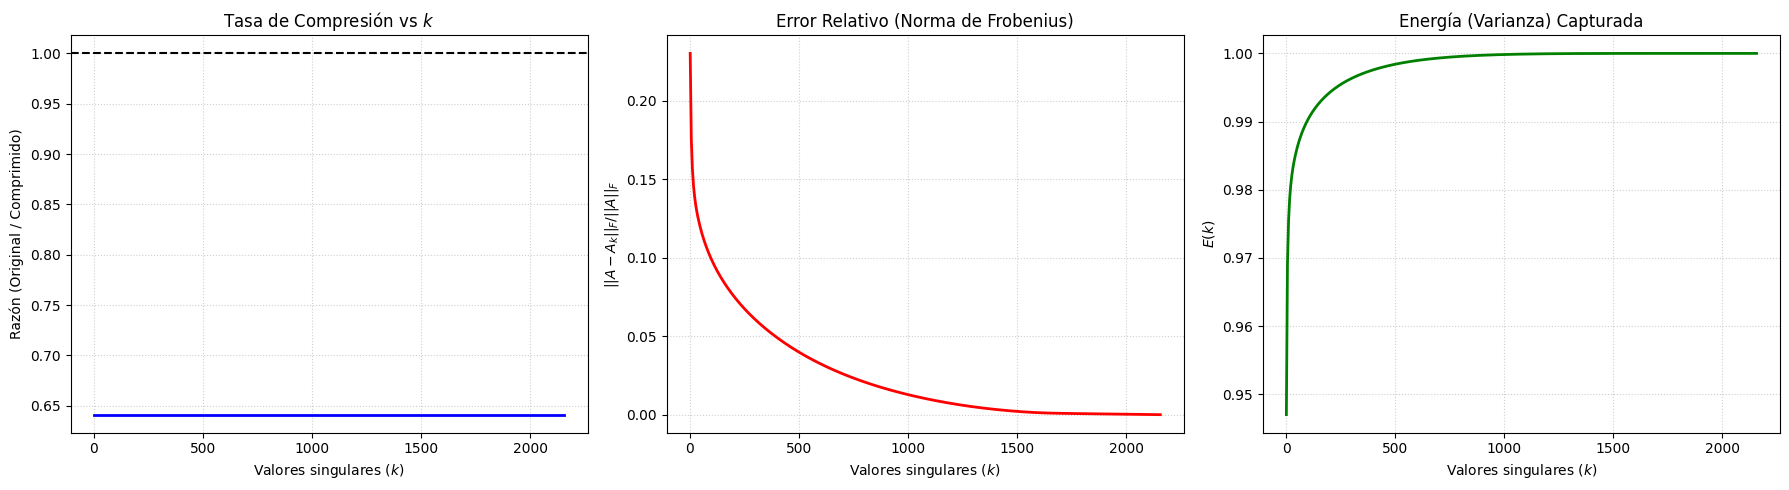

In [ ]:

r = len(S)

paso = 1 if r < 300 else (2 if r < 800 else 5)
k_range = np.arange(1, r + 1, paso)

tasas_compresion = []
errores_relativos = []
energias = []

energia_total = np.sum(S**2)
norma_A = np.sqrt(energia_total)
tamano_original = m * n

for k in k_range:

    tasa = tamano_original / datos_Ak
    tasas_compresion.append(tasa)

    error_k = np.sqrt(np.sum(S[k:]**2)) / norma_A
    errores_relativos.append(error_k)

    energia_k = np.sum(S[:k]**2) / energia_total
    energias.append(energia_k)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(k_range, tasas_compresion, color='blue', linewidth=2)
axs[0].axhline(1, color='black', linestyle='--')
axs[0].set_title('Tasa de Compresión vs $k$')
axs[0].set_xlabel('Valores singulares ($k$)')
axs[0].set_ylabel('Razón (Original / Comprimido)')
axs[0].grid(True, linestyle=':', alpha=0.6)

axs[1].plot(k_range, errores_relativos, color='red', linewidth=2)
axs[1].set_title('Error Relativo (Norma de Frobenius)')
axs[1].set_xlabel('Valores singulares ($k$)')
axs[1].set_ylabel('$||A-A_k||_F / ||A||_F$')
axs[1].grid(True, linestyle=':', alpha=0.6)

axs[2].plot(k_range, energias, color='green', linewidth=2)
axs[2].set_title('Energía (Varianza) Capturada')
axs[2].set_xlabel('Valores singulares ($k$)')
axs[2].set_ylabel('$E(k)$')
axs[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

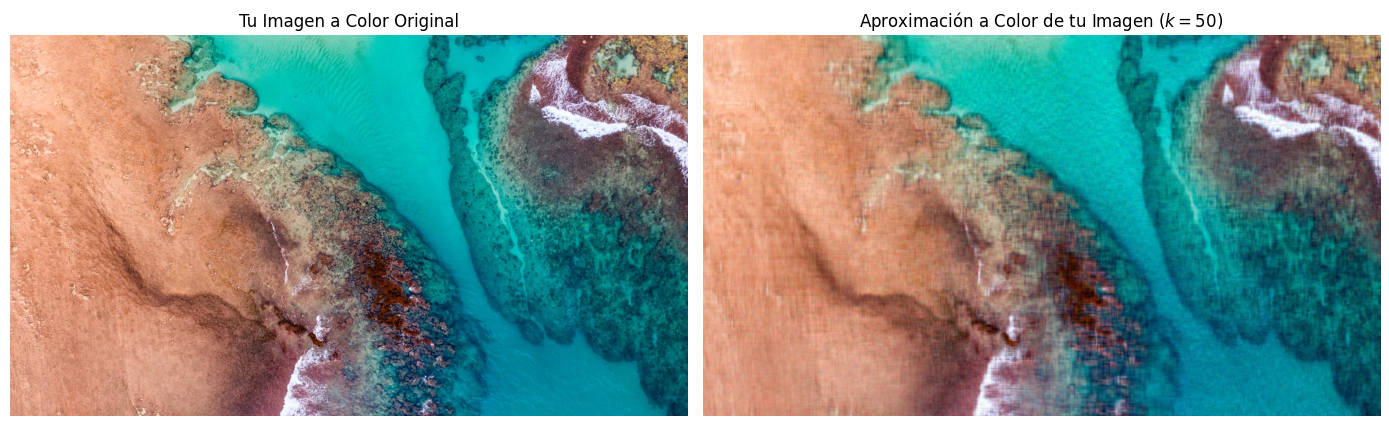

In [ ]:


def comprimir_color_svd(imagen_rgb, k):
    img_reconstruida = np.zeros_like(imagen_rgb, dtype=np.float64)

    for canal in range(3):
        A_canal = imagen_rgb[:, :, canal]

        # Calcular SVD del canal
        U_c, S_c, Vt_c = np.linalg.svd(A_canal, full_matrices=False)

        k_actual = min(k, len(S_c))

        # Aproximación de rango k para el canal
        A_k_canal = U_c[:, :k_actual] @ np.diag(S_c[:k_actual]) @ Vt_c[:k_actual, :]

        # Guardar en la matriz reconstruida
        img_reconstruida[:, :, canal] = A_k_canal

    img_reconstruida = np.clip(img_reconstruida, 0, 255)
    return img_reconstruida.astype(np.uint8)


if len(imagen_usuario.shape) == 3:
    k_bonus = 50

    imagen_bonus = comprimir_color_svd(imagen_usuario, k_bonus)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    ax[0].imshow(imagen_usuario)
    ax[0].set_title('Tu Imagen a Color Original')
    ax[0].axis('off')

    ax[1].imshow(imagen_bonus)
    ax[1].set_title(f'Aproximación a Color de tu Imagen ($k={k_bonus}$)')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("[-] El Bonus requiere una imagen a color (RGB).")
    print(f"La imagen que subiste actualmente es monocromática (escala de grises) con dimensiones {imagen_usuario.shape}.")
    print("Para ejecutar esta sección, prueba subiendo una foto a color en la primera celda.")